# Models for Savitzky-Golay 2. derivative data

#### Imports

In [50]:
# Data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Model selection and validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    learning_curve,
)

from sklearn.utils.class_weight import compute_sample_weight

# Pre-processing
from sklearn.preprocessing import (
    LabelEncoder,
    LabelBinarizer,
)
from scipy.signal import savgol_filter

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cross_decomposition import PLSRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from xgboost import XGBClassifier

# Metrics and evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    make_scorer,
)

In [51]:
plt.style.use("dark_background")

In [52]:
df = pd.read_csv("tobacco-nir-all.csv")

In [53]:
#  Dataframe with 4 targets instead of 6
df["Country4"] = df["Country"].replace({
    "Brazil":    "Brazil",
    "USA":       "USA",
    "Zimbabwe":  "Zimbabwe",
    "Argentina": "Argentina/Tanzania/Zambia",
    "Zambia":    "Argentina/Tanzania/Zambia",
    "Tanzania":  "Argentina/Tanzania/Zambia",
})

# 2) Identify metadata and spectral columns
meta_cols = ['Sample ID', 'Planting year', 'Country', 'Country4']
spec_cols = [c for c in df.columns if c not in meta_cols]

## Data splitting

In [54]:
# Feature matrix X and labels y (4-classes)
X = df[spec_cols].values
y = df['Country4'].values

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Pre-processing after split

In [56]:
# SNV
def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, ddof=1, keepdims=True)
    return (X - mean) / std

# Savitzky-Golay (2. derivative)
X_train_sg2 = savgol_filter(X_train, window_length=17, polyorder=2, deriv=2, axis=1)
X_test_sg2  = savgol_filter(X_test,  window_length=17, polyorder=2, deriv=2, axis=1)

X_train_sg2_snv = snv(X_train_sg2)
X_test_sg2_snv  = snv(X_test_sg2)

In [57]:
# Mean centering
def mean_center_fit(X_train):
    return X_train.mean(axis=0)

def mean_center_transform(X, mean):
    return X - mean

# SG 2. derivative + SNV
mean_sg2_snv = mean_center_fit(X_train_sg2_snv)
X_train_sg2_snv_mc = mean_center_transform(X_train_sg2_snv, mean_sg2_snv)
X_test_sg2_snv_mc  = mean_center_transform(X_test_sg2_snv,  mean_sg2_snv)

X_train = X_train_sg2_snv_mc
X_test = X_test_sg2_snv_mc

## Models

#### Helper function for plotting the learning curve of the different functions

In [58]:
f1_macro_scorer = make_scorer(f1_score, average='macro')

def compute_learning_curve(estimator, X, y, cv, n_points=10):
    """Return train_sizes, train_scores, val_scores for macro F1."""
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X, y,
        cv=cv,
        scoring=f1_macro_scorer,
        train_sizes=np.linspace(0.1, 1.0, n_points),
        n_jobs=-1,
    )
    return train_sizes, train_scores, val_scores

### Random forest

In [ ]:
rf = RandomForestClassifier(
    class_weight='balanced',   # Important measure since we have very imbalanced data
    random_state=42
)

# Hyperparameter-tuning with GridSearch
param_grid = {
    'n_estimators': [490],
    'max_depth': [None],
    'min_samples_split': [2],
    'max_features': [None],
    'min_samples_leaf': [1],

    ## Overview of hyperparameter searched over: 

    # 'n_estimators': [450, 490, 500],
    # 'max_depth': [None, 2, 5],
    # 'min_samples_split': [2, 5],
    # 'max_features': [None, 'sqrt', 'log2'],
    # 'min_samples_leaf': [1, 2, 5],
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=cv,                
    scoring='f1_macro',   
    n_jobs=-1             
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None], 'max_features': [None],
                         'min_samples_leaf': [1], 'min_samples_split': [2],
                         'n_estimators': [490]},
             scoring='f1_macro')

In [60]:
print("Beste parametere:", grid_rf.best_params_)
print("Beste CV F1-score:", grid_rf.best_score_)

Beste parametere: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 490}
Beste CV F1-score: 0.8763414271143264


#### Learning curve

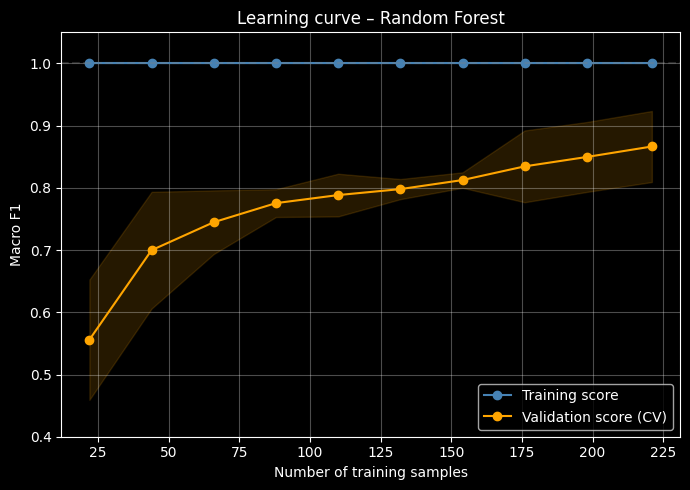

In [61]:
def plot_rf_learning_curve(best_rf, X_train, y_train, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        best_rf,
        X_train, y_train,
        cv=cv,
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(7, 5))

    # Training score
    plt.plot(
        train_sizes, train_mean,
        'o-', color='steelblue',
        label='Training score'
    )
    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15, color='steelblue'
    )

    # Validation score (CV)
    plt.plot(
        train_sizes, val_mean,
        'o-', color='orange',
        label='Validation score (CV)'
    )
    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15, color='orange'
    )

    plt.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
    plt.xlabel('Number of training samples')
    plt.ylabel('Macro F1')
    plt.title('Learning curve – Random Forest')
    plt.ylim([0.4, 1.05])
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


best_rf = grid_rf.best_estimator_
plot_rf_learning_curve(best_rf, X_train, y_train, cv)


### k-Nearest Neighbour (kNN)

In [62]:
# Text labels encoded to numbers.
le_knn = LabelEncoder()
y_train_enc = le_knn.fit_transform(y_train)
y_test_enc  = le_knn.transform(y_test)

knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    knn,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train_enc)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(1, 31),
                         'weights': ['uniform', 'distance']},
             scoring='f1_macro')

In [63]:
print("Beste parametere:", grid_knn.best_params_)
print("Beste CV F1-score:", grid_knn.best_score_)

Beste parametere: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Beste CV F1-score: 0.8276099661011347


#### Learning curve

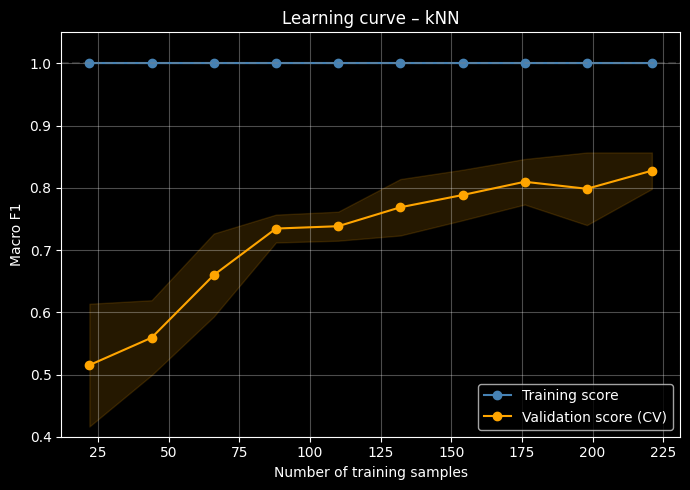

In [64]:
def plot_knn_learning_curve(best_knn, X_train, y_train_enc, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        best_knn,
        X_train, y_train_enc,
        cv=cv,
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(7, 5))

    # Training score
    plt.plot(
        train_sizes, train_mean,
        'o-', color='steelblue',
        label='Training score'
    )
    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15, color='steelblue'
    )

    # Validation score (CV)
    plt.plot(
        train_sizes, val_mean,
        'o-', color='orange',
        label='Validation score (CV)'
    )
    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15, color='orange'
    )

    plt.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
    plt.xlabel('Number of training samples')
    plt.ylabel('Macro F1')
    plt.title('Learning curve – kNN')
    plt.ylim([0.4, 1.05])
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


best_knn = grid_knn.best_estimator_
plot_knn_learning_curve(best_knn, X_train, y_train_enc, cv)


I am aware that I ideally I make a helper-function for the learning curve functions, instead of duplicating for each model, but unfortunately we had some issues with it... I hope it can be excused

### Support Vector Machine (SVM)

In [65]:
svm = SVC(
    class_weight='balanced',   
    random_state=42,
    probability=True           
)

param_grid = [
    {
        'kernel': ['linear', 'poly'],
        'C': [0.001, 0.01, 0.1, 1, 10, 11],
    },
    
    {
        # 'kernel': ['rbf'],
        # 'C': [0.01, 0.1, 1, 10, 100],
        # 'gamma': ['scale', 0.01, 0.001],
    }
]

grid_svm = GridSearchCV(
    svm,
    param_grid,
    cv=cv,
    scoring='f1_macro', 
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(class_weight='balanced', probability=True,
                           random_state=42),
             n_jobs=-1,
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 10, 11],
                          'kernel': ['linear', 'poly']},
                         {}],
             scoring='f1_macro')

In [66]:
print("Beste parametere:", grid_svm.best_params_)
print("Beste CV F1-score:", grid_svm.best_score_)

Beste parametere: {'C': 10, 'kernel': 'linear'}
Beste CV F1-score: 0.9251394677837993


#### Learning Curve

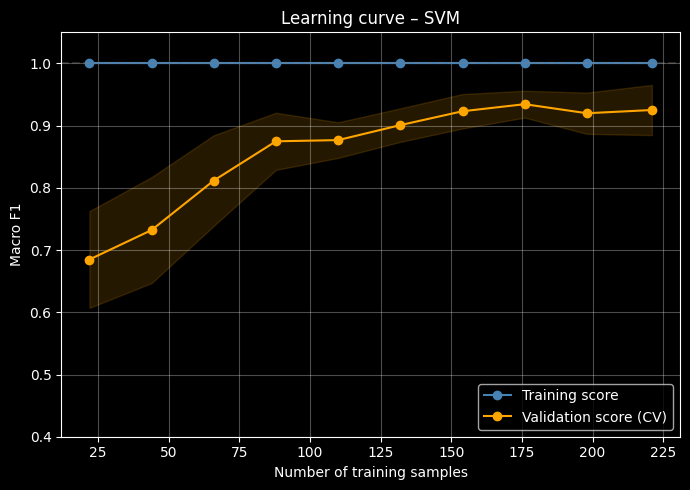

In [67]:
def plot_svm_learning_curve(best_svm, X_train, y_train, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        best_svm,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_macro',        
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        error_score='raise'
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(7, 5))

    # Training score
    plt.plot(
        train_sizes, train_mean,
        'o-', color='steelblue',
        label='Training score'
    )
    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15, color='steelblue'
    )

    # Validation score (CV)
    plt.plot(
        train_sizes, val_mean,
        'o-', color='orange',
        label='Validation score (CV)'
    )
    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15, color='orange'
    )

    plt.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
    plt.xlabel('Number of training samples')
    plt.ylabel('Macro F1')
    plt.title('Learning curve – SVM')
    plt.ylim([0.4, 1.05])
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


best_svm = grid_svm.best_estimator_
plot_svm_learning_curve(best_svm, X_train, y_train, cv)

#### Partial Least Squares Discirimant Analysis (PLS-DA)

In [68]:
# PLS-DA build as a sklearn-compatible classifier
class PLSDA(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=5):
        self.n_components = n_components

    def fit(self, X, y):
        self.lb_ = LabelBinarizer()
        Y = self.lb_.fit_transform(y)
        self.classes_ = self.lb_.classes_

        self.pls_ = PLSRegression(n_components=self.n_components)
        self.pls_.fit(X, Y)
        return self

    def predict(self, X):
        Y_pred = self.pls_.predict(X)       # Continous scores
        idx = np.argmax(Y_pred, axis=1)     # Choose class with best score
        return self.classes_[idx]

    def predict_proba(self, X):
        Y_pred = self.pls_.predict(X)
        # Normalizaton to [0,1] for probability
        Y_pred -= Y_pred.min(axis=1, keepdims=True)
        Y_pred /= Y_pred.sum(axis=1, keepdims=True) + 1e-9
        return Y_pred

plsda = PLSDA()

param_grid = {
    'n_components': list(range(1, 31)) 
}

grid_plsda = GridSearchCV(
    plsda,
    param_grid,
    cv=cv,             
    scoring='f1_macro',
    n_jobs=-1
)

grid_plsda.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=PLSDA(), n_jobs=-1,
             param_grid={'n_components': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                          13, 14, 15, 16, 17, 18, 19, 20, 21,
                                          22, 23, 24, 25, 26, 27, 28, 29, 30]},
             scoring='f1_macro')

In [69]:
print("Beste antall LV:", grid_plsda.best_params_)
print("Beste CV F1-score:", grid_plsda.best_score_)

Beste antall LV: {'n_components': 14}
Beste CV F1-score: 0.9043061361818914


#### Learning curve

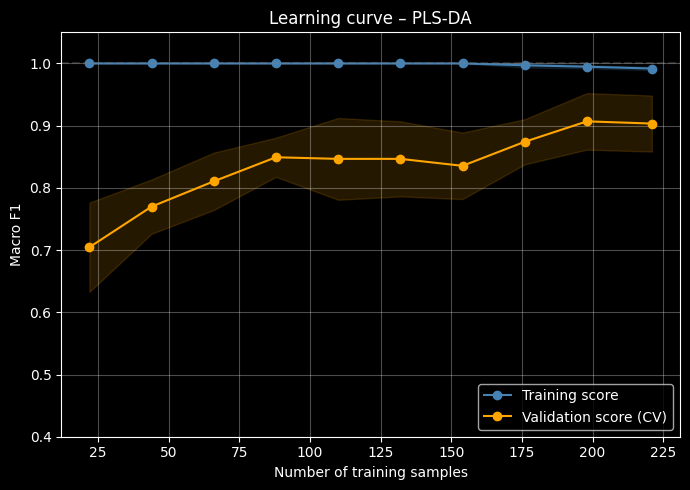

In [70]:
def plot_plsda_learning_curve(best_plsda, X_train, y_train, cv):
    # Macro-averaged F1 scorer
    f1_macro_scorer = make_scorer(f1_score, average='macro')

    train_sizes, train_scores, val_scores = learning_curve(
        best_plsda,
        X_train, y_train,
        cv=cv,
        scoring=f1_macro_scorer,
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(7, 5))

    # Training score
    plt.plot(
        train_sizes, train_mean,
        'o-', color='steelblue',
        label='Training score'
    )
    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15, color='steelblue'
    )

    # Validation score (CV)
    plt.plot(
        train_sizes, val_mean,
        'o-', color='orange',
        label='Validation score (CV)'
    )
    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15, color='orange'
    )

    plt.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
    plt.xlabel('Number of training samples')
    plt.ylabel('Macro F1')
    plt.title('Learning curve – PLS-DA')
    plt.ylim([0.4, 1.05])
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


best_plsda = grid_plsda.best_estimator_
plot_plsda_learning_curve(best_plsda, X_train, y_train, cv)


### XGBoost

In [71]:
# XGBoost requires numerical labels, so we encode the text labels to numbers.
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Balanced sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

xgb = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [150],
    'max_depth': [5],
    'learning_rate': [0.3],
    'subsample': [0.6]
    # 'n_estimators': [149, 150, 151],
    # 'max_depth': [2, 3, 4, 5, 7],
    # 'learning_rate': [0.01, 0.1, 0.3, 0.05],
    # 'subsample': [0.6, 0.7, 0.9, 1.0, 1.1]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train_enc, sample_weight=sample_weights)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.3], 'max_depth': [5],
                         'n_estimators': [150], 'subsample': [0.6]},
             scoring='f1_macro')

In [72]:
print("Beste parametere:", grid_xgb.best_params_)
print("Beste CV F1-score:", grid_xgb.best_score_)

Beste parametere: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.6}
Beste CV F1-score: 0.914480238565296


#### Learning curve

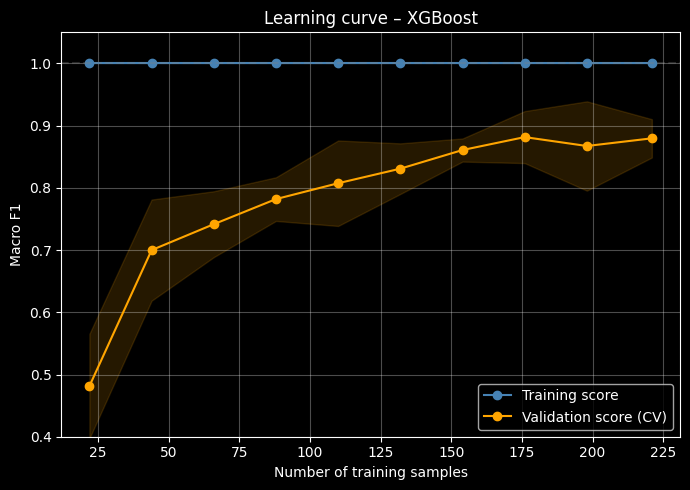

In [73]:
def plot_xgb_learning_curve(best_xgb, X_train, y_train_enc, cv):
    # Macro-averaged F1 scorer
    f1_macro_scorer = make_scorer(f1_score, average='macro')

    train_sizes, train_scores, val_scores = learning_curve(
        best_xgb,
        X_train, y_train_enc,
        cv=cv,
        scoring=f1_macro_scorer,
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(7, 5))

    # Training score
    plt.plot(
        train_sizes, train_mean,
        'o-', color='steelblue',
        label='Training score'
    )
    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15, color='steelblue'
    )

    # Validation score (CV)
    plt.plot(
        train_sizes, val_mean,
        'o-', color='orange',
        label='Validation score (CV)'
    )
    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15, color='orange'
    )

    plt.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
    plt.xlabel('Number of training samples')
    plt.ylabel('Macro F1')
    plt.title('Learning curve – XGBoost')
    plt.ylim([0.4, 1.05])
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


best_xgb = grid_xgb.best_estimator_
plot_xgb_learning_curve(best_xgb, X_train, y_train_enc, cv)

# Results and evaluation

In [74]:
class_names = ['Argentina/Tanzania/Zambia', 'Brazil', 'USA', 'Zimbabwe']

#### Get best models and predictions

In [75]:
# Get best models
best_rf    = grid_rf.best_estimator_
best_knn = grid_knn.best_estimator_
best_svm   = grid_svm.best_estimator_
best_plsda = grid_plsda.best_estimator_
best_xgb   = grid_xgb.best_estimator_

# Predictions on the testset
y_pred_rf    = best_rf.predict(X_test)

y_pred_knn_enc = best_knn.predict(X_test)
y_pred_knn     = le_knn.inverse_transform(y_pred_knn_enc)

y_pred_svm   = best_svm.predict(X_test)

# XGBoost and kNN were trained on encoded labels so we transform them back to text
y_pred_xgb_enc = best_xgb.predict(X_test)
y_pred_xgb     = le.inverse_transform(y_pred_xgb_enc)

y_pred_plsda = best_plsda.predict(X_test)

## Performance metrics

#### Confusion matrix and classification reports

=== Random Forest ===
                           precision    recall  f1-score   support

Argentina/Tanzania/Zambia       0.55      0.75      0.63         8
                   Brazil       0.93      0.96      0.95        27
                      USA       1.00      1.00      1.00         9
                 Zimbabwe       0.95      0.81      0.88        26

                 accuracy                           0.89        70
                macro avg       0.86      0.88      0.86        70
             weighted avg       0.90      0.89      0.89        70



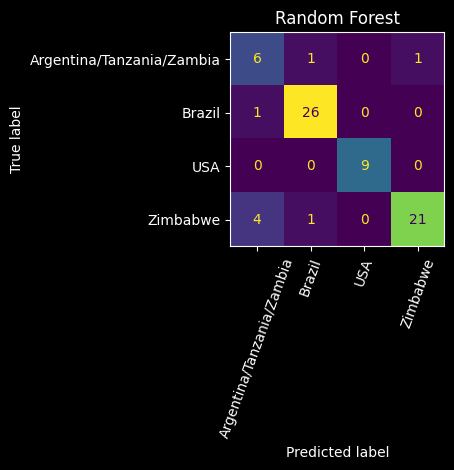

=== kNN ===
                           precision    recall  f1-score   support

Argentina/Tanzania/Zambia       0.70      0.88      0.78         8
                   Brazil       0.90      0.96      0.93        27
                      USA       1.00      1.00      1.00         9
                 Zimbabwe       0.95      0.81      0.88        26

                 accuracy                           0.90        70
                macro avg       0.89      0.91      0.90        70
             weighted avg       0.91      0.90      0.90        70



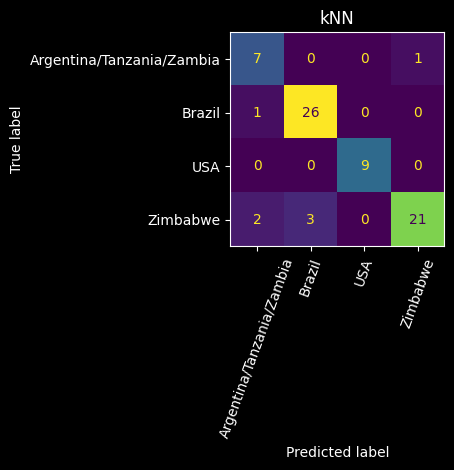

=== SVM ===
                           precision    recall  f1-score   support

Argentina/Tanzania/Zambia       0.86      0.75      0.80         8
                   Brazil       0.96      1.00      0.98        27
                      USA       1.00      1.00      1.00         9
                 Zimbabwe       0.92      0.92      0.92        26

                 accuracy                           0.94        70
                macro avg       0.94      0.92      0.93        70
             weighted avg       0.94      0.94      0.94        70



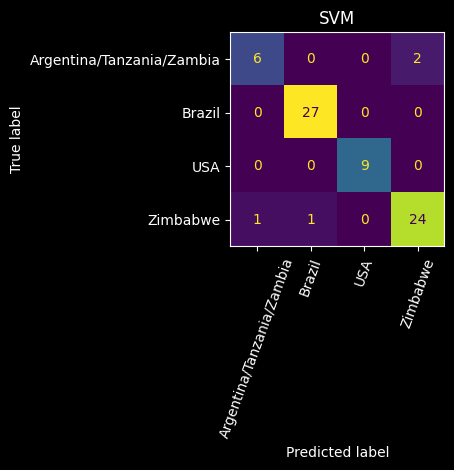

=== XGBoost ===
                           precision    recall  f1-score   support

Argentina/Tanzania/Zambia       0.70      0.88      0.78         8
                   Brazil       0.93      0.96      0.95        27
                      USA       1.00      1.00      1.00         9
                 Zimbabwe       0.91      0.81      0.86        26

                 accuracy                           0.90        70
                macro avg       0.89      0.91      0.90        70
             weighted avg       0.91      0.90      0.90        70



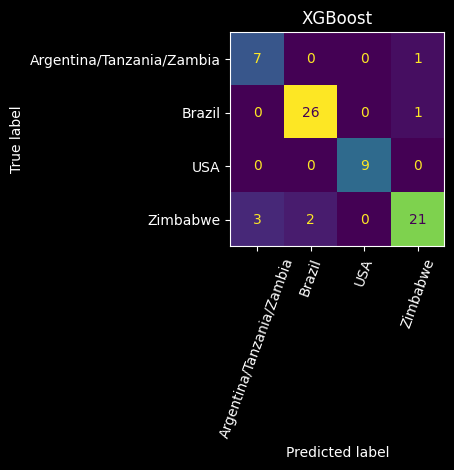

=== PLS-DA ===
                           precision    recall  f1-score   support

Argentina/Tanzania/Zambia       1.00      0.62      0.77         8
                   Brazil       0.96      1.00      0.98        27
                      USA       1.00      1.00      1.00         9
                 Zimbabwe       0.89      0.96      0.93        26

                 accuracy                           0.94        70
                macro avg       0.96      0.90      0.92        70
             weighted avg       0.95      0.94      0.94        70



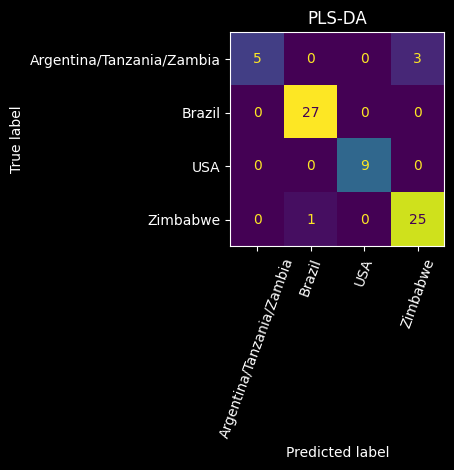

In [96]:
models = {
    'Random Forest': y_pred_rf,
    'kNN':           y_pred_knn,
    'SVM':           y_pred_svm,
    'XGBoost':       y_pred_xgb,
    'PLS-DA':        y_pred_plsda,
}

results = []

for name, y_pred in models.items():
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=class_names))
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(colorbar=False, xticks_rotation=70)
    plt.title(name)
    plt.tight_layout()
    plt.show()


#### Confusion matrices of all models (for the report)

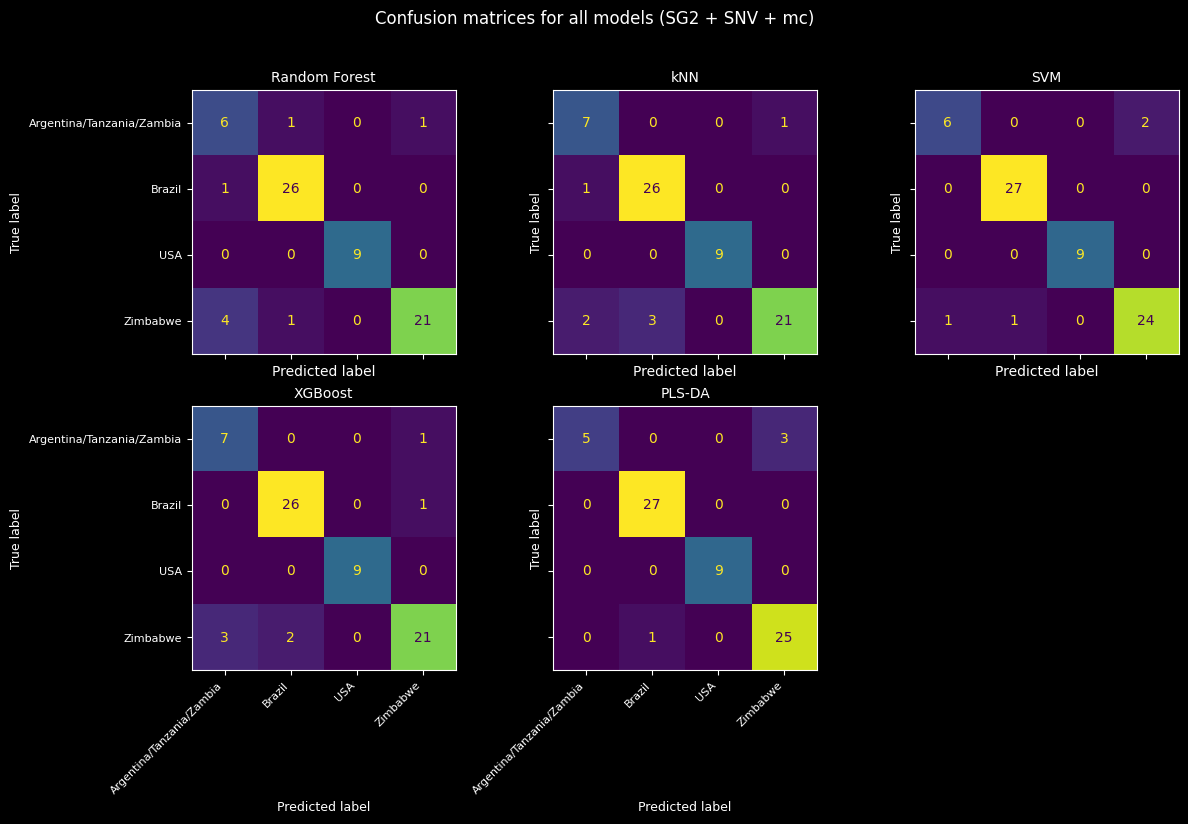

In [111]:
# Confusion matrices of all models (for the report)

n_rows, n_cols = 2, 3  # 2 rows × 3 columns → up to 6 panels
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4*n_cols, 4*n_rows),
    sharex=True, sharey=True  # same axes scale for all matrices
)
axes = axes.ravel()  # flatten to 1D for easy indexing

for i, (name, y_pred) in enumerate(models.items()):
    ax = axes[i]
    cm = confusion_matrix(y_test, y_pred, labels=class_names)

    # Use ConfusionMatrixDisplay with the default colormap
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(ax=ax, colorbar=False)

    ax.set_title(name, fontsize=10)

    # Show class names on the y-axis for all subplots
    ax.set_yticklabels(class_names, fontsize=8)

    # Show x-axis class names only on the bottom row to avoid clutter
    if i // n_cols == n_rows - 1:
        ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
        ax.set_xlabel("Predicted label", fontsize=9)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel("True label", fontsize=9)

# Remove unused axes if there are fewer than 6 models
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

fig.suptitle("Confusion matrices for all models (SG2 + SNV + mc)", y=1.02)
plt.tight_layout()
plt.show()

#### Overfitting analysis 

In [116]:
models_overfit = {
    'Random Forest': (best_rf,   X_train, X_test),
    'kNN':           (best_knn,  X_train, X_test),
    'SVM':           (best_svm,  X_train, X_test),
    'XGBoost':       (best_xgb,  X_train, X_test),
    'PLS-DA':        (best_plsda,X_train, X_test),
}

overfit_rows = []

for name, (model, X_tr, X_te) in models_overfit.items():
    # Prediction on train/test
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    # Decoding of encoded labels if needed:
    if name == 'kNN':
        y_pred_train = le_knn.inverse_transform(y_pred_train)
        y_pred_test  = le_knn.inverse_transform(y_pred_test)

    if name == 'XGBoost':
        y_pred_train = le.inverse_transform(y_pred_train)
        y_pred_test  = le.inverse_transform(y_pred_test)

    f1_train = f1_score(y_train, y_pred_train, average='macro')
    f1_test  = f1_score(y_test,  y_pred_test,  average='macro')

    overfit_rows.append({
        'Model':   name,
        'F1 Train': f1_train,
        'F1 Test':  f1_test,
        'Gap':      f1_train - f1_test,
    })

df_overfit = pd.DataFrame(overfit_rows).set_index('Model')
print(df_overfit.round(3).to_string())


               F1 Train  F1 Test    Gap
Model                                  
Random Forest     1.000    0.863  0.137
kNN               1.000    0.895  0.105
SVM               1.000    0.926  0.074
XGBoost           1.000    0.895  0.105
PLS-DA            0.991    0.919  0.072


#### Summary with performance and overfitting gap

In [117]:
summary_rows = []
for name, y_pred in models.items():
    summary_rows.append({
        'Model':         name,
        'Accuracy':       accuracy_score(y_test, y_pred),
        'Macro F1':       f1_score(y_test, y_pred, average='macro'),
        'Weighted F1':    f1_score(y_test, y_pred, average='weighted'),
    })

df_results = pd.DataFrame(summary_rows).set_index('Model')

df_combined = df_results.join(df_overfit[['F1 Train', 'F1 Test', 'Gap']])

print(df_combined.round(3).to_string())

               Accuracy  Macro F1  Weighted F1  F1 Train  F1 Test    Gap
Model                                                                   
Random Forest     0.886     0.863        0.890     1.000    0.863  0.137
kNN               0.900     0.895        0.901     1.000    0.895  0.105
SVM               0.943     0.926        0.942     1.000    0.926  0.074
XGBoost           0.900     0.895        0.901     1.000    0.895  0.105
PLS-DA            0.943     0.919        0.939     0.991    0.919  0.072


## All learning curves

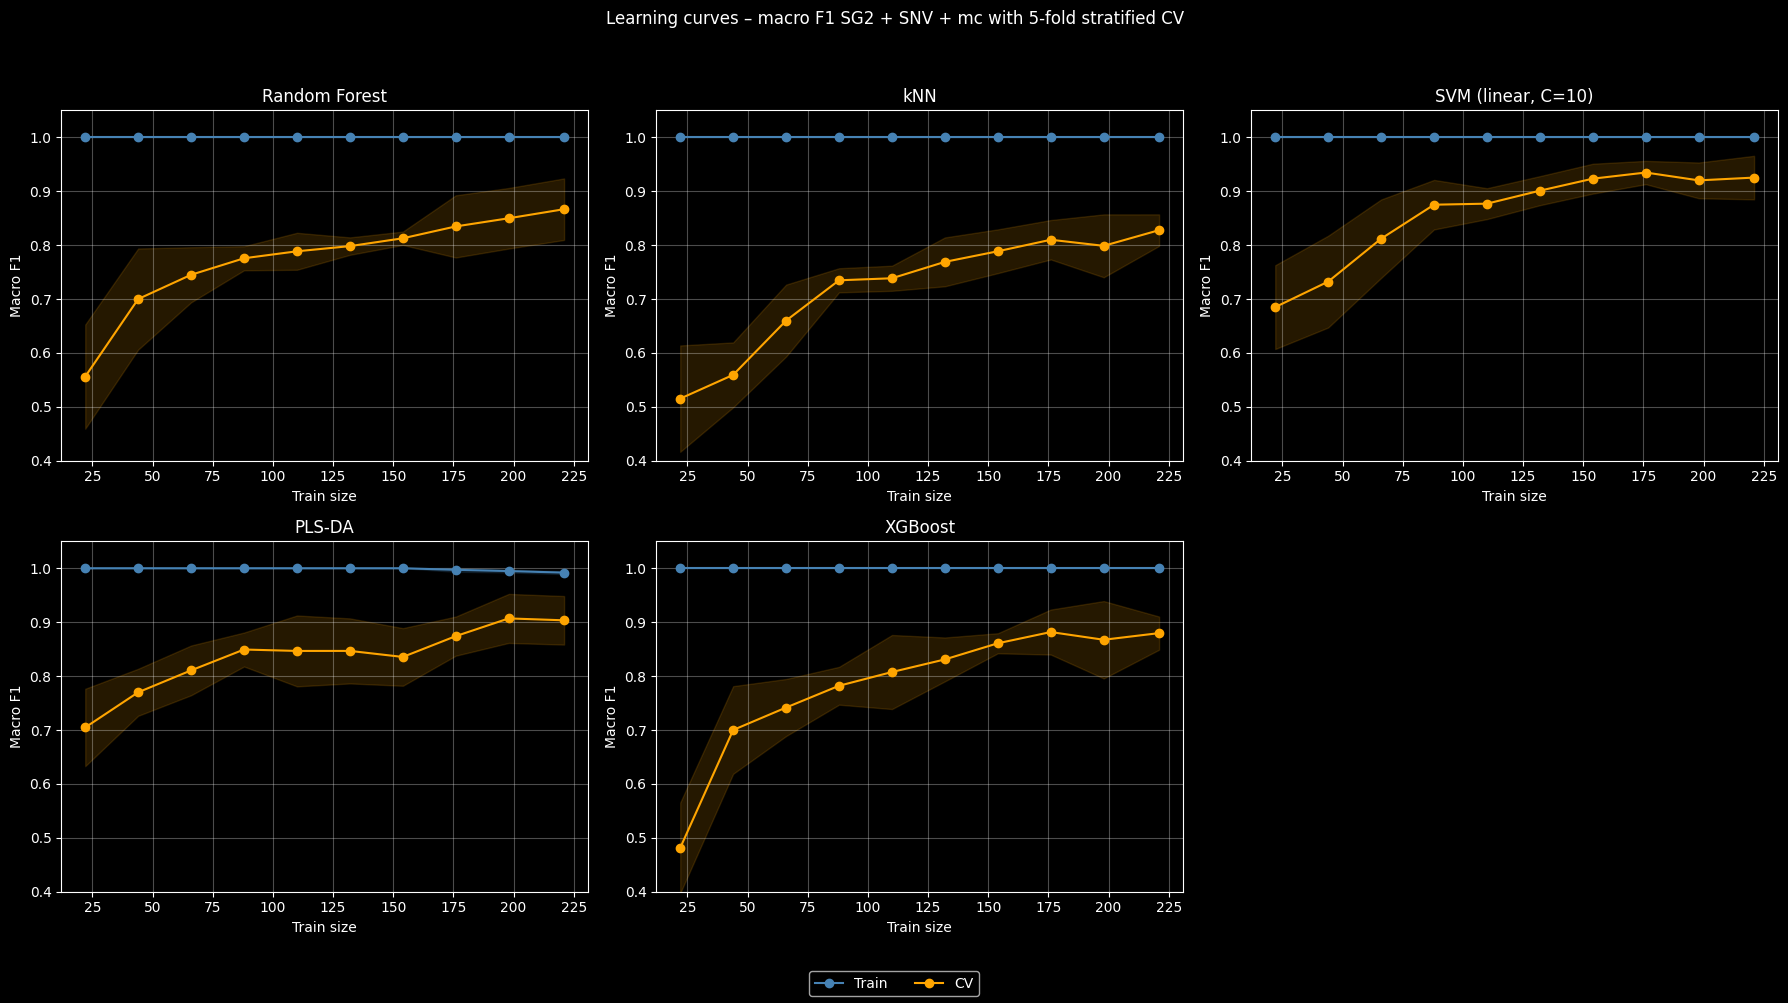

In [122]:
def plot_learning_curves_grid():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    # Random Forest
    ax = axes[0]
    train_sizes, train_scores, val_scores = learning_curve(
        best_rf,
        X_train, y_train,
        cv=cv,
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='CV')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='orange')
    ax.set_title("Random Forest")
    ax.set_xlabel("Train size")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0.4, 1.05)
    ax.grid(alpha=0.3)

    # kNN
    ax = axes[1]
    train_sizes, train_scores, val_scores = learning_curve(
        best_knn,
        X_train, y_train_enc, 
        cv=cv,
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='CV')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='orange')
    ax.set_title("kNN")
    ax.set_xlabel("Train size")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0.4, 1.05)
    ax.grid(alpha=0.3)

    # SVM
    ax = axes[2]
    train_sizes, train_scores, val_scores = learning_curve(
        best_svm,
        X_train, y_train,
        cv=cv,
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        error_score='raise'
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='CV')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='orange')
    ax.set_title("SVM (linear, C=10)")
    ax.set_xlabel("Train size")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0.4, 1.05)
    ax.grid(alpha=0.3)

    # PLS-DA
    ax = axes[3]
    train_sizes, train_scores, val_scores = learning_curve(
        best_plsda,
        X_train, y_train,
        cv=cv,
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='CV')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='orange')
    ax.set_title("PLS-DA")
    ax.set_xlabel("Train size")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0.4, 1.05)
    ax.grid(alpha=0.3)

    # XGBoost
    ax = axes[4]
    train_sizes, train_scores, val_scores = learning_curve(
        best_xgb,
        X_train, y_train_enc, 
        cv=cv,
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='CV')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='orange')
    ax.set_title("XGBoost")
    ax.set_xlabel("Train size")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0.4, 1.05)
    ax.grid(alpha=0.3)

    # Second row, third column is empty 
    axes[5].axis('off')  

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=2)

    fig.suptitle("Learning curves – macro F1 SG2 + SNV + mc with 5-fold stratified CV", y=0.99)
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()

plot_learning_curves_grid()